In [3]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
from pandas.api.types import CategoricalDtype
import scipy as sp
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color

In [330]:
askfile = filedialog.askopenfile() # show an "Open" dialog box and select the file


In [331]:
data = pd.read_csv(askfile, encoding='utf-8')
data

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
0,Track_121830,0,5,0,0,0,0,0,4,1,...,0.500,1.000,0.000,1.000,0.577,11.879,13.540,10.083,11.991,1.378
1,Track_121831,1,2,0,0,0,0,0,1,1,...,0.827,0.827,0.827,0.827,NaN,6.970,7.318,6.622,7.318,0.348
2,Track_121832,2,3,0,0,0,0,0,2,0,...,0.129,0.189,0.070,0.189,0.084,7.077,7.706,6.546,6.980,0.478
3,Track_121833,3,34,5,3,0,0,0,41,0,...,0.659,1.975,0.037,0.525,0.468,9.503,16.703,5.595,8.623,3.101
4,Track_121834,4,41,5,4,0,0,0,48,0,...,0.402,1.414,0.000,0.000,0.493,9.518,13.846,6.162,9.292,1.987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15275,Track_137105,15275,2,0,0,0,0,0,1,498,...,2.646,2.646,2.646,2.646,NaN,7.275,7.852,6.699,7.852,0.576
15276,Track_137106,15276,2,0,0,0,0,0,1,498,...,0.579,0.579,0.579,0.579,NaN,8.839,9.520,8.159,9.520,0.680
15277,Track_137107,15277,2,0,0,0,0,0,1,498,...,3.982,3.982,3.982,3.982,NaN,5.687,5.758,5.617,5.758,0.070
15278,Track_137108,15278,2,0,0,0,0,0,1,498,...,1.230,1.230,1.230,1.230,NaN,6.506,6.957,6.056,6.957,0.450


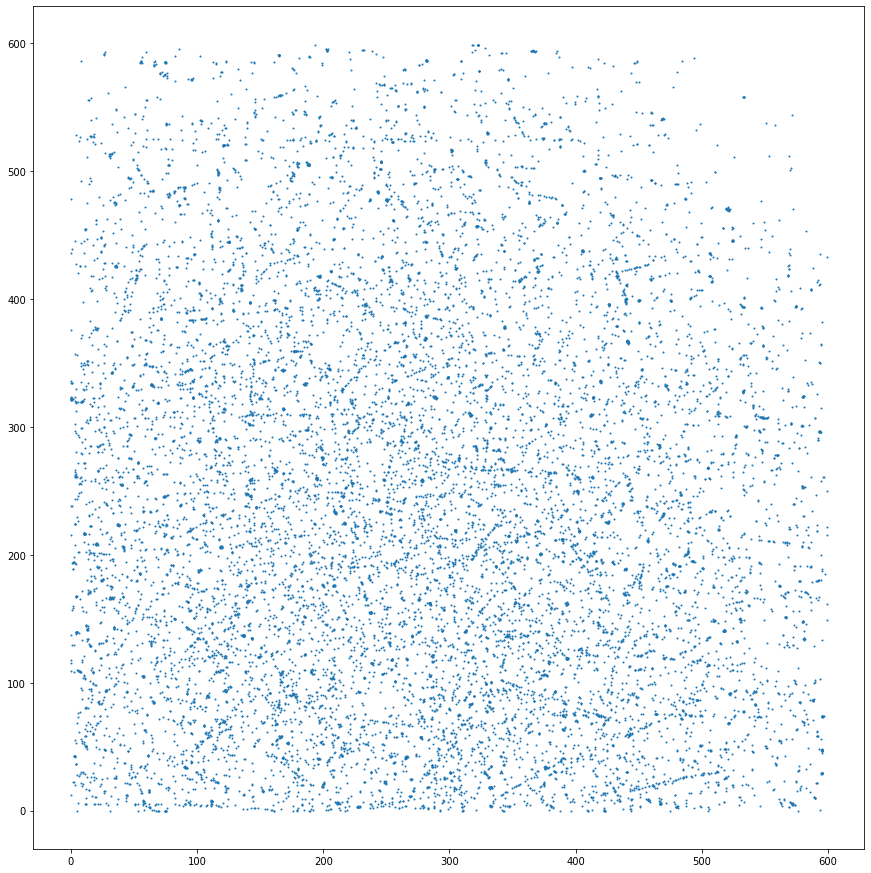

In [332]:
x=data['TRACK_X_LOCATION']
y=data['TRACK_Y_LOCATION']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45*2,7.75*2))
ax.scatter(x , y , s = scattersize)

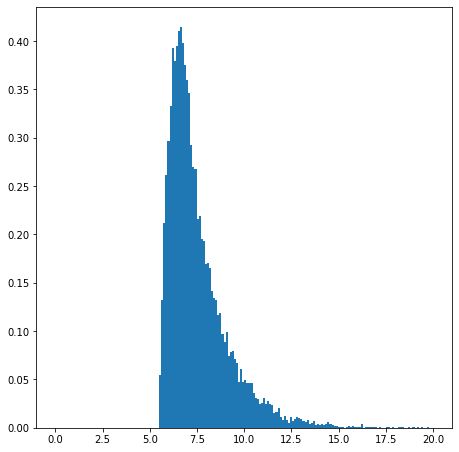

In [333]:
y=data['TRACK_MEDIAN_QUALITY']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 20 + 0.11, 0.11), density=True);

In [372]:
data0 = data[(data['TRACK_START']>5) & (data['TRACK_STOP']<495) & (data['TRACK_DURATION']>3)& (data['TRACK_MEDIAN_QUALITY']>6)]
data0

,Label,TRACK_ID,NUMBER_SPOTS,NUMBER_GAPS,LONGEST_GAP,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,TRACK_DURATION,TRACK_START,...,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TRACK_MAX_QUALITY,TRACK_MIN_QUALITY,TRACK_MEDIAN_QUALITY,TRACK_STD_QUALITY
726,Track_122556,726,12,0,0,0,0,0,11,7,...,0.780,1.897,0.063,0.736,0.515,6.932,9.778,5.606,6.957,1.206
731,Track_122561,731,16,0,0,0,0,0,15,7,...,0.602,1.040,0.216,0.515,0.314,8.369,12.690,5.850,8.422,1.626
735,Track_122565,735,5,1,3,0,0,0,7,6,...,0.571,1.048,0.087,0.655,0.398,7.183,8.640,5.512,7.292,1.023
736,Track_122566,736,11,2,3,0,0,0,15,7,...,0.761,1.410,0.122,0.986,0.458,7.124,9.294,5.510,6.679,1.278
737,Track_122567,737,5,0,0,0,0,0,4,6,...,0.476,0.785,0.250,0.513,0.232,8.268,10.846,5.840,8.805,1.753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15087,Track_136917,15087,5,1,1,0,0,0,5,487,...,1.170,1.847,0.833,1.057,0.460,6.848,8.422,6.151,6.664,0.814
15094,Track_136924,15094,5,0,0,0,0,0,4,488,...,0.796,1.228,0.375,0.792,0.349,7.034,8.425,6.073,6.996,0.884
15097,Track_136927,15097,4,1,3,0,0,0,6,488,...,0.608,0.891,0.428,0.503,0.249,6.943,8.063,5.966,6.940,0.746
15113,Track_136943,15113,4,1,2,0,0,0,5,489,...,0.595,1.036,0.159,0.591,0.438,6.129,7.173,5.620,6.016,0.621


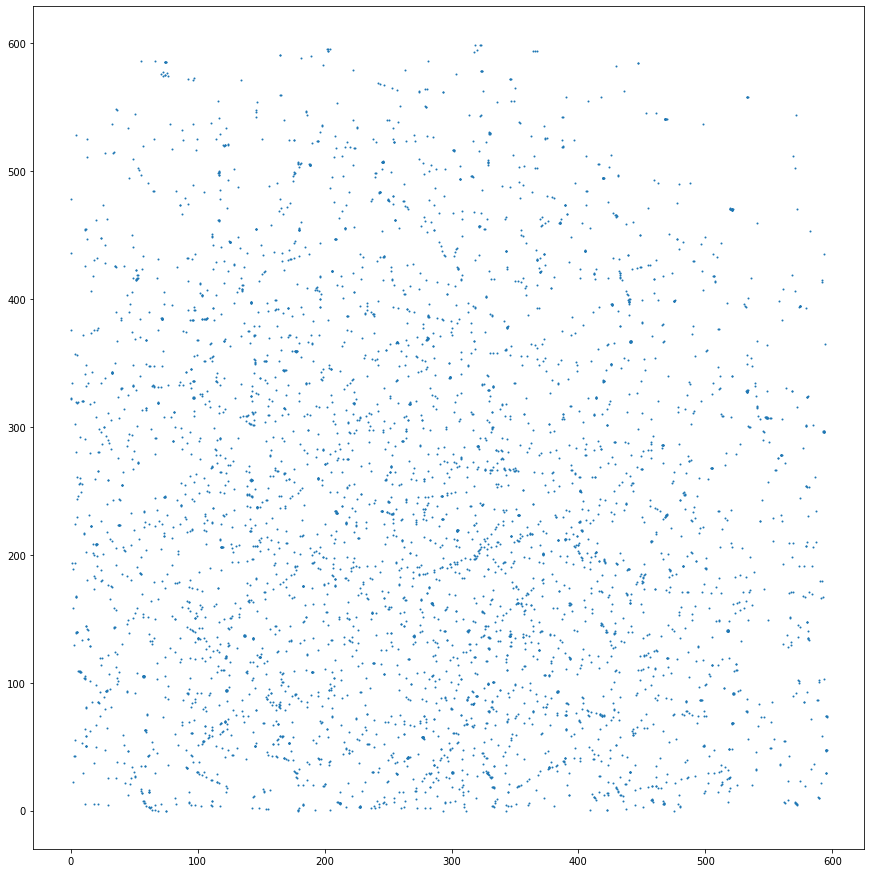

In [373]:
x=data0['TRACK_X_LOCATION']
y=data0['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*2,7.75*2))
ax.scatter(x , y , s = scattersize)

In [374]:
def filter_neighbors(data0,xy,R,N):
    xy = data0[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
    for i in list(xy.index): #
        
        xyvalue = xy.loc[i].values
        xvalue = xyvalue[0]
        yvalue = xyvalue[1]
        
        square = xy[(xy['TRACK_X_LOCATION']<(xvalue+R)) & (xy['TRACK_X_LOCATION']>(xvalue-R)) & (xy['TRACK_Y_LOCATION']<(yvalue+R)) & (xy['TRACK_Y_LOCATION']>(yvalue-R))]
        
        if len(square) < N:
            try:
                data0 = data0.drop(square.index)
            except KeyError:
                 continue

    return data0

def filter_correlation(data0,xy,R,C):
    xy = data0[['TRACK_X_LOCATION','TRACK_Y_LOCATION']]
    for i in list(xy.index): #
        
        xyvalue = xy.loc[i].values
        xvalue = xyvalue[0]
        yvalue = xyvalue[1]
        
        square = xy[(xy['TRACK_X_LOCATION']<(xvalue+R)) & (xy['TRACK_X_LOCATION']>(xvalue-R)) & (xy['TRACK_Y_LOCATION']<(yvalue+R)) & (xy['TRACK_Y_LOCATION']>(yvalue-R))]
        
        column_1 = square['TRACK_X_LOCATION']
        column_2 = square['TRACK_Y_LOCATION']
        correlation = column_1.corr(column_2)
        
        if correlation < abs(C):
            try:
                data0 = data0.drop(square.index)
            except KeyError:
                 continue

    return data0

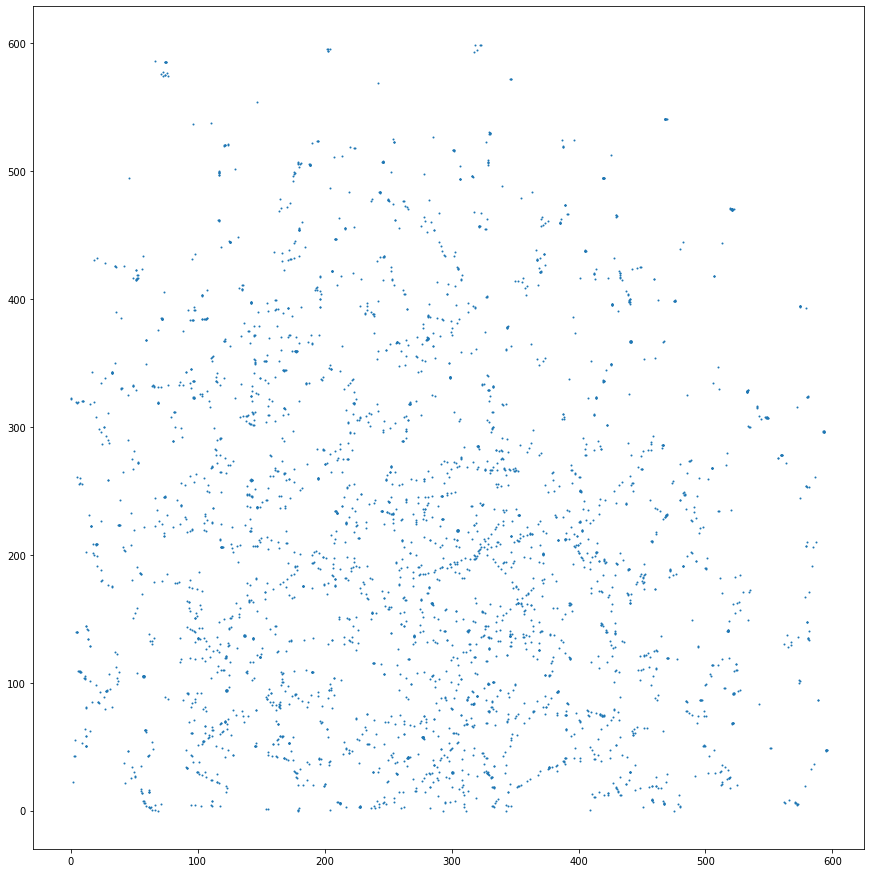

In [379]:
data1 = filter_neighbors(data0,xy,10,5)

x=data1['TRACK_X_LOCATION']
y=data1['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*2,7.75*2))
ax.scatter(x , y , s = scattersize)

C:\ProgramData\Anaconda3\lib\site-packages\numpy\lib\function_base.py:2526: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar)
C:\ProgramData\Anaconda3\lib\site-packages\numpy\lib\function_base.py:2455: RuntimeWarning: divide by zero encountered in true_divide
  c *= np.true_divide(1, fact)


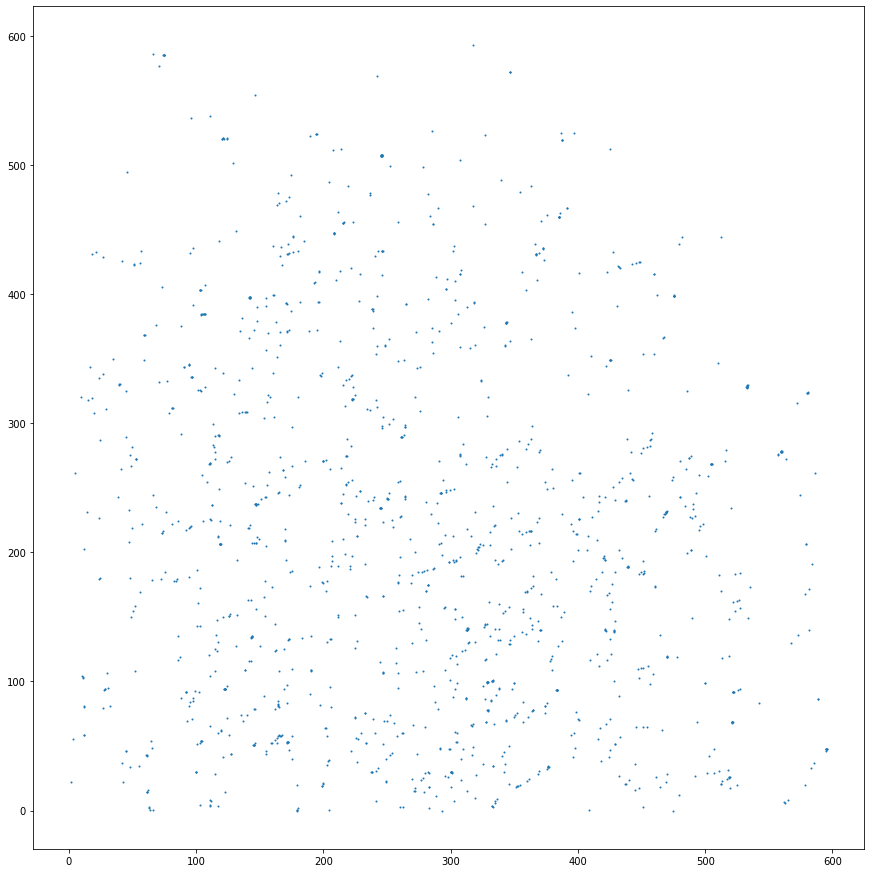

In [385]:
data2 = filter_correlation(data1,xy,5,0.5)
x=data2['TRACK_X_LOCATION']
y=data2['TRACK_Y_LOCATION']
fig, ax = plt.subplots(1,1,figsize=(7.45*2,7.75*2))
ax.scatter(x , y , s = scattersize)

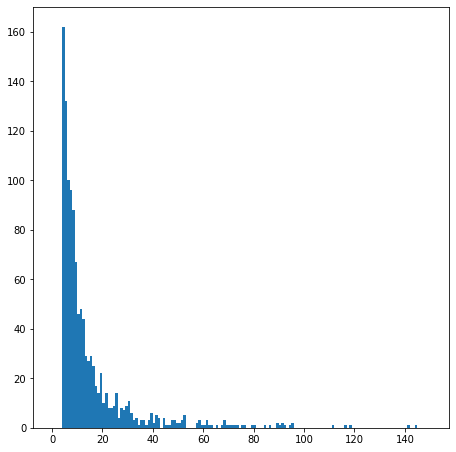

In [384]:
y=data2['TRACK_DURATION']
scattersize = 1
cap = 5
fig, ax = plt.subplots(1,1,figsize=(7.45,7.75))
ax.hist(y, bins=np.arange(0, 150 + 1, 1));

In [ ]:
def exponential(x, scale):
    return ((np.exp(-x/scale) )/(scale))

def make_hist(data, parameter, tubconc, dcxtype, dcxconc) :
    
    selectdata = data[(data[tubulin]==tubconc)&(data[Type]==dcxtype)&(data[DCXconc]==dcxconc)]
    
    if parameter == GrowthRate :
        maxbin = 1.5
        binsize = 0.05
#     elif parameter == ShrinkageRate :
#         maxbin = 15
#         binsize = 0.1
    else:
        maxbin = 30
        binsize = 1
        
    n, bins, patches = plt.hist(selectdata[parameter], bins=np.arange(0, maxbin + binsize, binsize), density=True);
    plt.clf()
       
    return n, bins